# PU Learning com TF-IDF de palavras e caracteres

Este notebook simula **Positive–Unlabeled Learning (PU)** no Fake.br-Corpus. Use-o como uma linha complementar aos detectores de anomalia: PU aprende com exemplos Fake conhecidos e exemplos sem rótulo, enquanto Isolation Forest, LOF e One-Class SVM aprendem o padrão das notícias True.

## Resumo do experimento

O notebook usa `texto_trunc` (até 200 palavras) do conjunto preparado nos notebooks supervisionados. O split tem 5.760 documentos para treino e 1.440 para teste. As features são TF-IDF de palavras (n-gramas 1–2) e caracteres (3–5), com **331.003 dimensões**.

No treino, P contém 2.880 notícias Fake conhecidas e U contém 2.880 notícias True sem rótulo. O método oculta 432 exemplos de P como *spies*, define o limiar `P(fake)=0,0600` e encontra 725 negativos confiáveis. A Random Forest final tem 300 árvores e é treinada em P e nos negativos selecionados. O conjunto de teste fica fora da seleção e do ajuste.

## Resultados no teste

| Métrica | Resultado |
|---|---:|
| Acurácia | 0,7347 |
| ROC-AUC | 0,9547 |
| Precisão / recall / F1 — Real | 0,9856 / 0,4764 / 0,6423 |
| Precisão / recall / F1 — Fake | 0,6548 / 0,9931 / 0,7892 |

Matriz de confusão (linhas: rótulo verdadeiro; colunas: previsão; ordem Real, Fake):

|  | Previsto Real | Previsto Fake |
|---|---:|---:|
| Real | 343 | 377 |
| Fake | 5 | 715 |

Com limiar 0,5, o recall Fake é alto, mas **377 das 720 notícias reais também foram classificadas como Fake**. Leia a ROC-AUC junto com esse custo no ponto de corte.

> **Limite da simulação:** U contém somente notícias reais, escolhidas pelos rótulos originais. Em um cenário PU real, U pode conter exemplos positivos e negativos; estes números não medem esse cenário misto. O split também difere do teste usado nos detectores de anomalia, então as métricas não são diretamente comparáveis.

Veja também a [documentação do método](docs/modelos/pu-learning.md) e o [comparativo dos experimentos](RESULTADOS.md).

## Importação dos dados preparados

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.sparse import vstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.pipeline import FeatureUnion

RANDOM_STATE = 42
POSITIVE_LABEL = 1
TEXT_COLUMN = "texto_trunc"
SPY_FRACTION = 0.15
TEMPORARY_ESTIMATORS = 200
FINAL_ESTIMATORS = 300
PREDICTION_THRESHOLD = 0.5

X_tr, X_te, y_tr, y_te = joblib.load("../supervised-learning/dados_preparados.pkl")

if TEXT_COLUMN not in X_tr.columns:
    raise KeyError(f"Coluna de texto ausente: {TEXT_COLUMN}")

print(f"Treino: {len(X_tr)} documentos | Teste: {len(X_te)} documentos")

Treino: 5760 documentos | Teste: 1440 documentos


## Construção dos conjuntos P e U

Para reproduzir o cenário PU com os dados rotulados disponíveis, mantemos apenas as notícias falsas (label 1) como positivas conhecidas. As notícias reais entram no conjunto não rotulado e não são usadas como rótulo durante as duas etapas de treinamento.

In [2]:
is_positive = y_tr.to_numpy() == POSITIVE_LABEL
positive_texts = X_tr.loc[is_positive, TEXT_COLUMN].fillna("").astype(str).tolist()
unlabeled_texts = X_tr.loc[~is_positive, TEXT_COLUMN].fillna("").astype(str).tolist()

if not positive_texts or not unlabeled_texts:
    raise ValueError("O conjunto de treino precisa conter exemplos positivos e não positivos.")

print(f"P (falsas conhecidas): {len(positive_texts)}")
print(f"U (não rotulados): {len(unlabeled_texts)}")

P (falsas conhecidas): 2880
U (não rotulados): 2880


## Extração das features TF-IDF

In [3]:
def build_text_vectorizer():
    return FeatureUnion([
        (
            "word_tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                analyzer="word",
                min_df=2,
                sublinear_tf=True,
            ),
        ),
        (
            "char_tfidf",
            TfidfVectorizer(
                ngram_range=(3, 5),
                analyzer="char",
                min_df=2,
                sublinear_tf=True,
            ),
        ),
    ])


text_vectorizer = build_text_vectorizer()
training_texts = positive_texts + unlabeled_texts
training_matrix = text_vectorizer.fit_transform(training_texts)
positive_count = len(positive_texts)
positive_matrix = training_matrix[:positive_count]
unlabeled_matrix = training_matrix[positive_count:]
test_matrix = text_vectorizer.transform(X_te[TEXT_COLUMN].fillna("").astype(str))

print(f"Features geradas: {training_matrix.shape[1]}")

Features geradas: 331003


## Etapa 1: identificação de negativos confiáveis com espiões

In [4]:
random_generator = np.random.default_rng(RANDOM_STATE)
spy_count = max(1, int(SPY_FRACTION * positive_matrix.shape[0]))
if positive_matrix.shape[0] > 1:
    spy_count = min(spy_count, positive_matrix.shape[0] - 1)

spy_indices = random_generator.choice(positive_matrix.shape[0], spy_count, replace=False)
clean_positive_indices = np.setdiff1d(np.arange(positive_matrix.shape[0]), spy_indices)

unlabeled_with_spies = vstack([unlabeled_matrix, positive_matrix[spy_indices]])
unlabeled_and_spy_labels = np.zeros(unlabeled_with_spies.shape[0], dtype=int)
positive_clean = positive_matrix[clean_positive_indices]
positive_clean_labels = np.ones(positive_clean.shape[0], dtype=int)

temporary_matrix = vstack([positive_clean, unlabeled_with_spies])
temporary_labels = np.concatenate([positive_clean_labels, unlabeled_and_spy_labels])
temporary_classifier = RandomForestClassifier(
    n_estimators=TEMPORARY_ESTIMATORS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
temporary_classifier.fit(temporary_matrix, temporary_labels)

unlabeled_and_spy_probabilities = temporary_classifier.predict_proba(unlabeled_with_spies)[:, 1]
spy_probabilities = unlabeled_and_spy_probabilities[-spy_count:]
spy_threshold = spy_probabilities.min()
reliable_negative_indices = np.flatnonzero(
    unlabeled_and_spy_probabilities[:unlabeled_matrix.shape[0]] < spy_threshold
)

print(f"Espiões selecionados: {spy_count}")
print(f"Limiar de negativo confiável: {spy_threshold:.4f}")
print(f"Negativos confiáveis encontrados: {len(reliable_negative_indices)}")

Espiões selecionados: 432
Limiar de negativo confiável: 0.0600
Negativos confiáveis encontrados: 725


## Diagnóstico da seleção

O classificador temporário produz `P(fake)` para cada documento. Como os espiões são exemplos falsos conhecidos artificialmente escondidos em U, o menor `P(fake)` entre eles define um limiar conservador. Assim:

- **P limpo**: falsos conhecidos usados para ensinar a classe positiva.
- **Espiões**: parte de P escondida em U para calibrar o limiar.
- **U**: documentos ainda não rotulados; não devem ser chamados de reais automaticamente.
- **RN**: documentos de U com `P(fake) < limiar`, selecionados como negativos confiáveis.

O gráfico abaixo permite verificar se os RN estão concentrados à esquerda da distribuição de U e se o limiar não está selecionando uma parcela excessiva ou insuficiente dos dados.

In [ ]:
unlabeled_probabilities = unlabeled_and_spy_probabilities[:unlabeled_matrix.shape[0]]
reliable_negative_mask = np.zeros(unlabeled_matrix.shape[0], dtype=bool)
reliable_negative_mask[reliable_negative_indices] = True

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [2, 1]},
)

axes[0].hist(
    unlabeled_probabilities[~reliable_negative_mask],
    bins=40,
    alpha=0.65,
    label="U não selecionado",
    color="steelblue",
)
axes[0].hist(
    unlabeled_probabilities[reliable_negative_mask],
    bins=40,
    alpha=0.85,
    label="RN selecionados",
    color="seagreen",
)
axes[0].hist(
    spy_probabilities,
    bins=min(20, max(5, spy_count // 10)),
    alpha=0.85,
    label="Espiões",
    color="darkorange",
)
axes[0].axvline(
    spy_threshold,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Limiar = {spy_threshold:.3f}",
)
axes[0].set_title("Distribuição de P(fake) na seleção")
axes[0].set_xlabel("Probabilidade estimada de fake")
axes[0].set_ylabel("Quantidade de documentos")
axes[0].legend()

set_labels = ["P limpo", "Espiões", "U", "RN"]
set_counts = [
    positive_clean.shape[0],
    spy_count,
    unlabeled_matrix.shape[0],
    len(reliable_negative_indices),
]
set_colors = ["#4472c4", "#ed7d31", "#a5a5a5", "#70ad47"]
axes[1].bar(set_labels, set_counts, color=set_colors)
axes[1].set_title("Estado dos conjuntos")
axes[1].set_ylabel("Quantidade de documentos")
for bar_index, set_count in enumerate(set_counts):
    axes[1].text(bar_index, set_count, f" {set_count}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

selection_summary = pd.DataFrame({
    "conjunto": set_labels,
    "quantidade": set_counts,
    "proporcao_de_U": [
        np.nan,
        spy_count / unlabeled_matrix.shape[0],
        1.0,
        len(reliable_negative_indices) / unlabeled_matrix.shape[0],
    ],
})
selection_summary

## Etapa 2: treinamento final com P e RN

In [5]:
if len(reliable_negative_indices) == 0:
    raise RuntimeError(
        "Nenhum negativo confiável foi encontrado; ajuste o spy_fraction ou revise os dados."
    )

reliable_negatives = unlabeled_matrix[reliable_negative_indices]
final_matrix = vstack([positive_matrix, reliable_negatives])
final_labels = np.concatenate([
    np.ones(positive_matrix.shape[0], dtype=int),
    np.zeros(reliable_negatives.shape[0], dtype=int),
])

final_classifier = RandomForestClassifier(
    n_estimators=FINAL_ESTIMATORS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_classifier.fit(final_matrix, final_labels)

print(f"Total de positivos usados: {positive_matrix.shape[0]}")
print(f"Total de negativos confiáveis usados: {reliable_negatives.shape[0]}")

Total de positivos usados: 2880
Total de negativos confiáveis usados: 725


## Avaliação no conjunto de teste

              precision    recall  f1-score   support

        real     0.9856    0.4764    0.6423       720
        fake     0.6548    0.9931    0.7892       720

    accuracy                         0.7347      1440
   macro avg     0.8202    0.7347    0.7158      1440
weighted avg     0.8202    0.7347    0.7158      1440

ROC-AUC: 0.9547


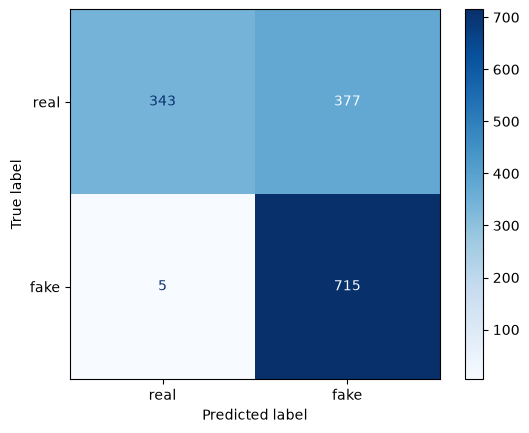

In [6]:
positive_probability = final_classifier.predict_proba(test_matrix)[:, 1]
predicted_labels = np.where(
    positive_probability >= PREDICTION_THRESHOLD,
    POSITIVE_LABEL,
    1 - POSITIVE_LABEL,
)

# O modelo pontua P como 1; ROC-AUC precisa pontuar fake como 1.
fake_scores = positive_probability if POSITIVE_LABEL == 1 else 1 - positive_probability

print(classification_report(y_te, predicted_labels, digits=4, target_names=["real", "fake"]))
print(f"ROC-AUC: {roc_auc_score(y_te, fake_scores):.4f}")
ConfusionMatrixDisplay.from_predictions(
    y_te,
    predicted_labels,
    display_labels=["real", "fake"],
    cmap="Blues",
)